# Bank Churn Analysis with XGBoost and AdaBoost

This notebook analyzes the **BankChurners** dataset, focusing on customer attrition (churn). We will:
1. **Load** and **clean** the data (removing unwanted columns and converting `Attrition_Flag` to a numeric `Churn`).
2. **Perform** exploratory data analysis (EDA) to understand churn distribution and feature relationships.
3. **Remove** outliers from numeric features (excluding `Churn`) and compare correlation matrices.
4. **Build** predictive models (Logistic Regression, Random Forest, **XGBoost**, and **AdaBoost**) to predict churn.

Let's begin!

## 1. Setup

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                             precision_recall_fscore_support)


plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


## 2. Data Loading

Ensure the **BankChurners.csv** file is in the same directory as this notebook.

In [2]:
# Load the dataset
df = pd.read_csv("BankChurners.csv")

# Display the first 5 rows
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3. Data Cleaning

### 3.1 Drop Unwanted Columns

We remove the following columns:
- `CLIENTNUM`
- Any columns generated by a Naive Bayes model (i.e., those starting with `Naive_Bayes_Classifier_...`)

In [3]:
# Define columns to drop
columns_to_drop = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

# Drop the specified columns
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("Columns removed.")
df.head()

Columns removed.


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### 3.2 Checking for Missing Values

We check for any missing values that might need to be addressed.

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values in each column:")
print(missing_values)

Missing Values in each column:
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


### 3.3 Create Numeric `Churn` Column

We keep the original `Attrition_Flag` for distribution plots. Then we create a numeric `Churn` column:
- `Existing Customer` → 0
- `Attrited Customer` → 1

In [5]:
# Map 'Attrition_Flag' to a binary numeric column 'Churn'
df['Churn'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

print("Unique values in Attrition_Flag:", df['Attrition_Flag'].unique())
print("Churn column created.")
df[['Attrition_Flag', 'Churn']].head()

Unique values in Attrition_Flag: ['Existing Customer' 'Attrited Customer']
Churn column created.


,Attrition_Flag,Churn
0,Existing Customer,0
1,Existing Customer,0
2,Existing Customer,0
3,Existing Customer,0
4,Existing Customer,0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of `Attrition_Flag`

We examine how many customers are attrited vs. existing.

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


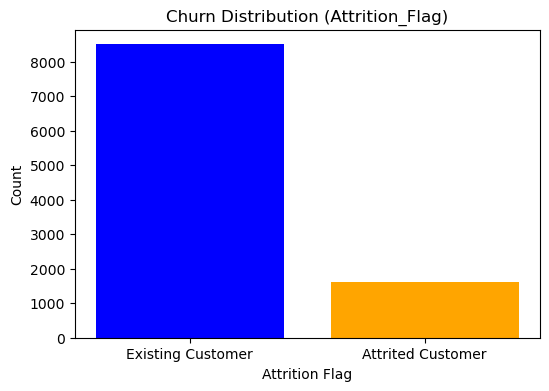

In [6]:
# Check distribution of Attrition_Flag
if 'Attrition_Flag' in df.columns:
    churn_counts = df['Attrition_Flag'].value_counts()
    print(churn_counts)

    # Bar plot
    plt.figure(figsize=(6,4))
    plt.bar(churn_counts.index, churn_counts.values, color=['blue','orange'])
    plt.title('Churn Distribution (Attrition_Flag)')
    plt.xlabel('Attrition Flag')
    plt.ylabel('Count')
    plt.show()
else:
    print("'Attrition_Flag' column not found.")

### 4.2 Outlier Removal

We remove outliers from all numeric columns **except** for `Churn`, using the IQR method.

In [7]:
# Create a copy for outlier removal
df_clean = df.copy()

# Identify numeric columns, excluding 'Churn'
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'Churn' in numeric_cols:
    numeric_cols.remove('Churn')

# Remove outliers using IQR
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

# Update df to the cleaned version
df = df_clean.copy()

Original shape: (10127, 21)
Cleaned shape: (6463, 21)


### 4.3 Data Overview (Post-Cleaning)

In [8]:
# View basic info after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6463 entries, 10 to 10125
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            6463 non-null   object 
 1   Customer_Age              6463 non-null   int64  
 2   Gender                    6463 non-null   object 
 3   Dependent_count           6463 non-null   int64  
 4   Education_Level           6463 non-null   object 
 5   Marital_Status            6463 non-null   object 
 6   Income_Category           6463 non-null   object 
 7   Card_Category             6463 non-null   object 
 8   Months_on_book            6463 non-null   int64  
 9   Total_Relationship_Count  6463 non-null   int64  
 10  Months_Inactive_12_mon    6463 non-null   int64  
 11  Contacts_Count_12_mon     6463 non-null   int64  
 12  Credit_Limit              6463 non-null   float64
 13  Total_Revolving_Bal       6463 non-null   int64  
 14  Avg_Open_To

In [9]:
# Summary statistics (including categorical columns)
df.describe(include='all')

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
count,6463,6463.000000,6463,6463.000000,6463,6463,6463,6463,6463.000000,6463.000000,...,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000
unique,2,NaN,2,NaN,7,4,6,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Existing Customer,NaN,F,NaN,Graduate,Married,Less than $40K,Blue,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5380,NaN,3988,NaN,2006,2994,2677,6341,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,46.384032,NaN,2.389138,NaN,NaN,NaN,NaN,35.951106,3.939192,...,2.497138,5084.608170,1140.233792,3944.374377,0.728738,3593.651710,62.892155,0.687565,0.320961,0.167569
std,NaN,7.506139,NaN,1.272785,NaN,NaN,NaN,NaN,7.036630,1.514048,...,0.930392,3921.874545,817.255076,3934.216696,0.162697,1568.378776,19.472826,0.181285,0.283666,0.373512
min,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,18.000000,1.000000,...,1.000000,1438.300000,0.000000,10.000000,0.293000,510.000000,10.000000,0.207000,0.000000,0.000000
25%,NaN,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,32.000000,3.000000,...,2.000000,2264.000000,0.000000,1018.000000,0.620000,2216.000000,46.000000,0.569000,0.000000,0.000000
50%,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,4.000000,...,3.000000,3359.000000,1250.000000,2229.000000,0.721000,3908.000000,67.000000,0.689000,0.260000,0.000000
75%,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,5.000000,...,3.000000,6841.000000,1766.500000,5712.500000,0.836000,4581.000000,79.000000,0.808000,0.570000,0.000000


### 4.4 Categorical Analysis

We analyze the average churn rate for key categorical variables.

=== Analysis for Gender ===
Churn Rate by Category:
Gender
F    0.178536
M    0.149899
Name: Churn, dtype: float64

Chi-square statistic: 8.7742
p-value: 0.0031
Degrees of freedom: 1
--------------------------------------------------


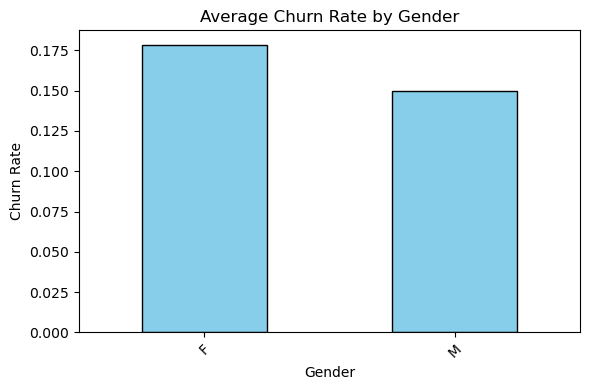

=== Analysis for Education_Level ===
Churn Rate by Category:
Education_Level
College          0.158133
Doctorate        0.230769
Graduate         0.166002
High School      0.148148
Post-Graduate    0.195652
Uneducated       0.164871
Unknown          0.177215
Name: Churn, dtype: float64

Chi-square statistic: 15.0267
p-value: 0.0201
Degrees of freedom: 6
--------------------------------------------------


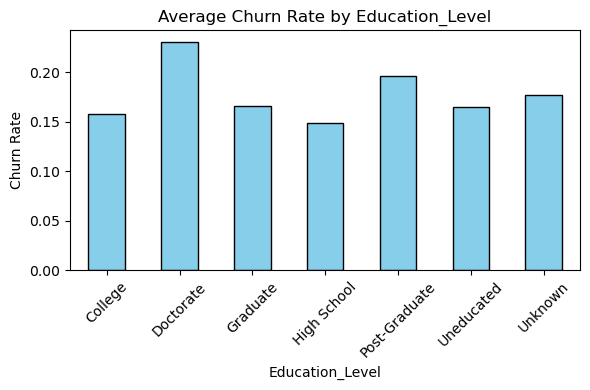

=== Analysis for Marital_Status ===
Churn Rate by Category:
Marital_Status
Divorced    0.173362
Married     0.163995
Single      0.168526
Unknown     0.179012
Name: Churn, dtype: float64

Chi-square statistic: 0.8607
p-value: 0.8349
Degrees of freedom: 3
--------------------------------------------------


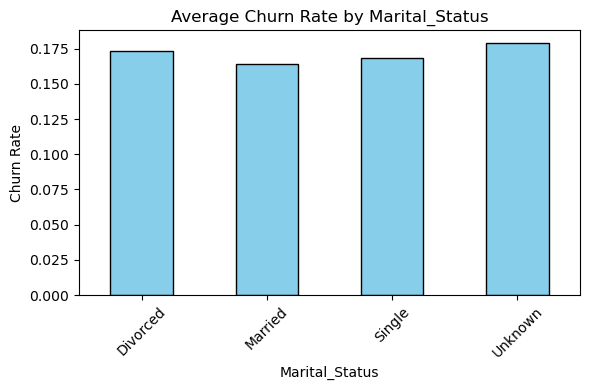

=== Analysis for Income_Category ===
Churn Rate by Category:
Income_Category
$120K +           0.181818
$40K - $60K       0.158631
$60K - $80K       0.140199
$80K - $120K      0.168539
Less than $40K    0.178558
Unknown           0.167131
Name: Churn, dtype: float64

Chi-square statistic: 7.7728
p-value: 0.1692
Degrees of freedom: 5
--------------------------------------------------


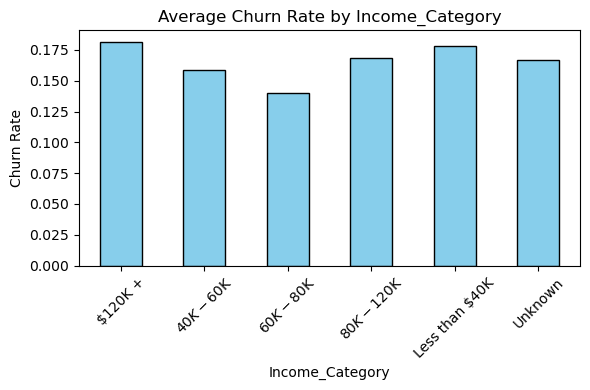

=== Analysis for Card_Category ===
Churn Rate by Category:
Card_Category
Blue        0.167955
Gold        0.187500
Platinum    0.666667
Silver      0.126214
Name: Churn, dtype: float64

Chi-square statistic: 6.6725
p-value: 0.0831
Degrees of freedom: 3
--------------------------------------------------


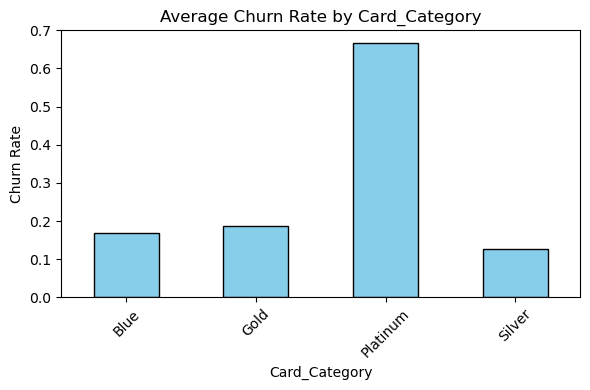

In [10]:
categorical_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]

for col in categorical_cols:
    if col in df.columns:
        print(f"=== Analysis for {col} ===")
        churn_rate = df.groupby(col)['Churn'].mean()
        print("Churn Rate by Category:")
        print(churn_rate)

        # Optional: Chi-square test
        contingency_table = pd.crosstab(df[col], df['Churn'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"\nChi-square statistic: {chi2:.4f}")
        print(f"p-value: {p:.4f}")
        print(f"Degrees of freedom: {dof}")
        print("-" * 50)

        # Plot bar chart
        plt.figure(figsize=(6, 4))
        churn_rate.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f"Average Churn Rate by {col}")
        plt.ylabel("Churn Rate")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column {col} not found in DataFrame.")

### 4.5 Numerical Feature Distributions

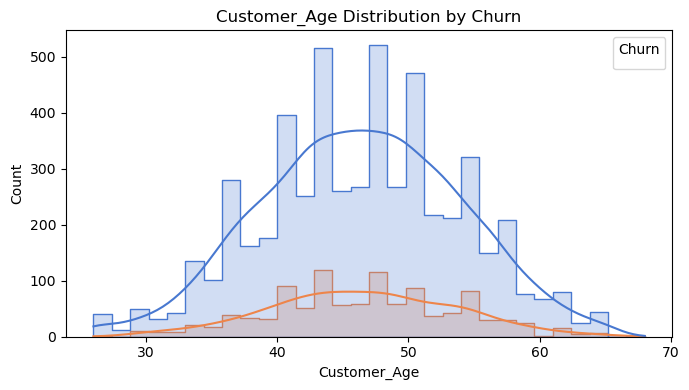

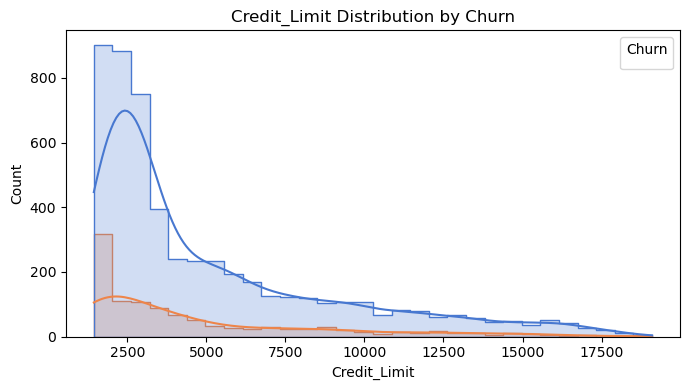

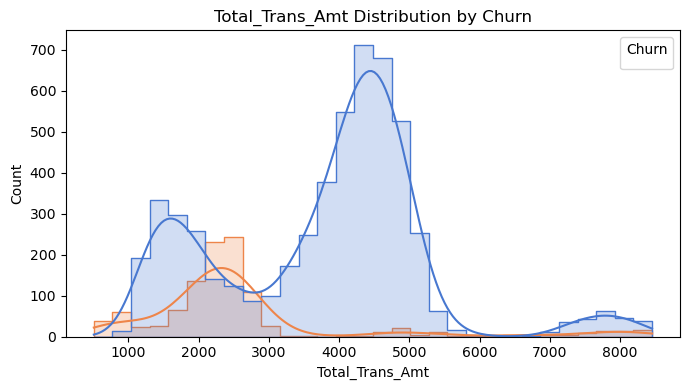

In [11]:
numeric_cols = ["Customer_Age", "Credit_Limit", "Total_Trans_Amt"]

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30, palette='muted', element='step')
        plt.title(f'{col} Distribution by Churn')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.legend(title='Churn')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column {col} not found.")

### 4.6 Correlation Analysis

We compute the correlation matrix for numeric features and display the values in an annotated heatmap.

Correlation Matrix:
                          Attrition_Flag  Customer_Age    Gender  \
Attrition_Flag                  1.000000     -0.009278  0.037272   
Customer_Age                   -0.009278      1.000000 -0.023811   
Gender                          0.037272     -0.023811  1.000000   
Dependent_count                -0.024272     -0.135834 -0.011034   
Education_Level                -0.003529      0.008192 -0.002455   
Marital_Status                 -0.006049     -0.011626 -0.006160   
Income_Category                -0.017686     -0.000016 -0.520549   
Card_Category                   0.010293     -0.004443 -0.044913   
Months_on_book                  0.000709      0.749380 -0.009002   
Total_Relationship_Count        0.166143     -0.027562  0.044467   
Months_Inactive_12_mon         -0.200456      0.041709 -0.002710   
Contacts_Count_12_mon          -0.126290     -0.017703  0.043994   
Credit_Limit                    0.040464      0.001984  0.338618   
Total_Revolving_Bal         

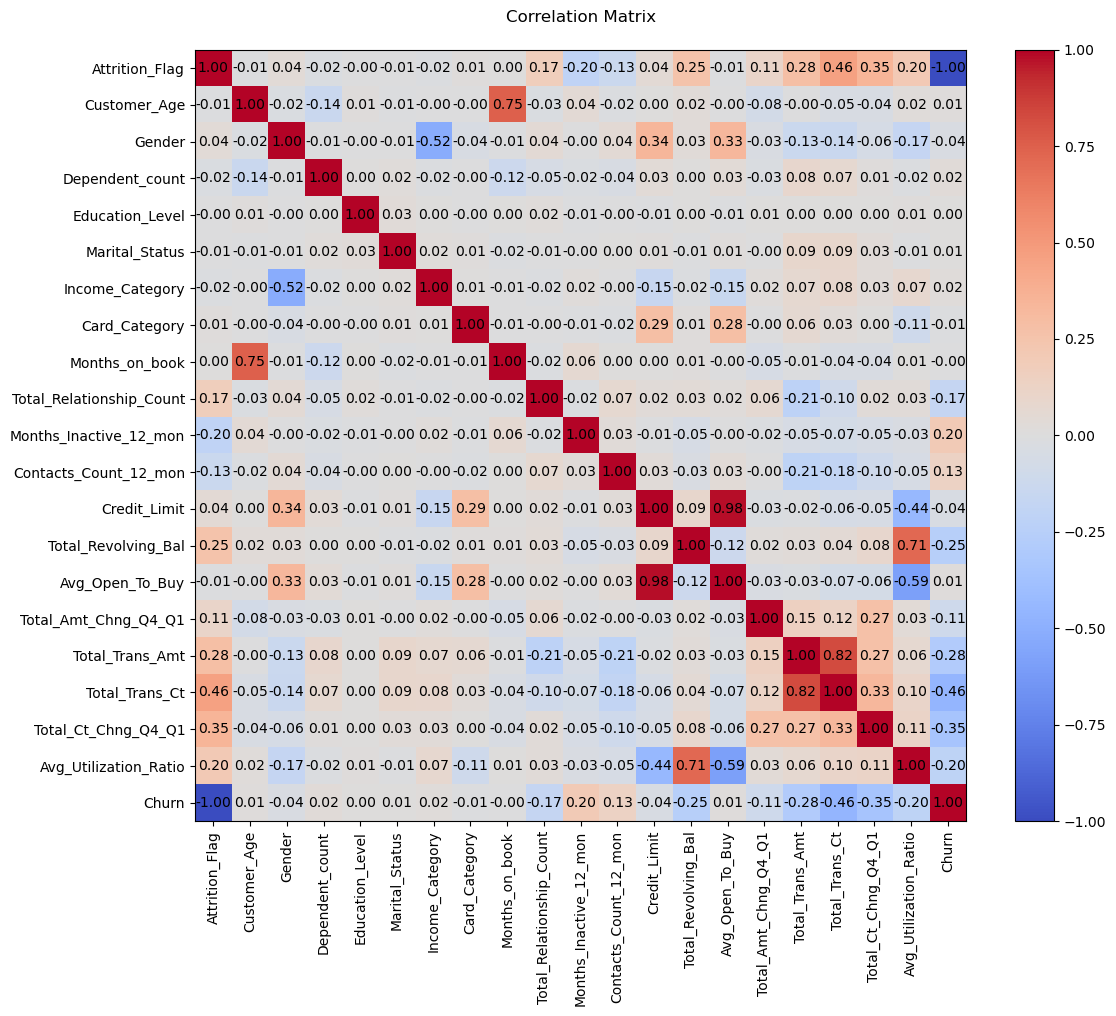

In [21]:
numeric_features = df.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(12, 10))
cax = plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(cax)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Annotate each cell
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

plt.title('Correlation Matrix', pad=20)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

# Assuming df is already loaded and the target is 'Churn'

# Step 1: Label Encode the categorical columns
label_encoder = LabelEncoder()

# Apply label encoding for each categorical column in the dataset
for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

# Split features and target
X = df.drop(columns=['Churn'])  # Features
y = df['Churn']  # Target

# Step 2: Correlation Coefficient Calculation (Pearson Correlation)
correlation_scores = {}

for feature in X.columns:
    correlation_scores[feature] = X[feature].corr(y)  # Pearson correlation

# Step 3: F-Score (ANOVA F-statistic) Calculation
f_scores, p_values = f_classif(X, y)

# Store the F-scores and their corresponding p-values
f_scores_dict = dict(zip(X.columns, f_scores))

# Step 4: Mutual Information Calculation
mutual_info = mutual_info_classif(X, y)

# Store the mutual information results
mi_scores = dict(zip(X.columns, mutual_info))

# Step 5: Rank the results from highest to lowest
sorted_correlation = sorted(correlation_scores.items(), key=lambda x: abs(x[1]), reverse=True)
sorted_f_scores = sorted(f_scores_dict.items(), key=lambda x: x[1], reverse=True)
sorted_mutual_info = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)

# Step 6: Print the ranked results

# Print Correlation Coefficients ranked from highest to lowest
print("Correlation Coefficients ranked from highest to lowest:")
for feature, corr in sorted_correlation:
    print(f"{feature}: Correlation = {corr:.4f}")

# Print F-scores ranked from highest to lowest
print("\nF-Scores (ANOVA F-statistic) ranked from highest to lowest:")
for feature, f_score in sorted_f_scores:
    print(f"{feature}: F-Score = {f_score:.4f}")

# Print Mutual Information ranked from highest to lowest
print("\nMutual Information ranked from highest to lowest:")
for feature, mi in sorted_mutual_info:
    print(f"{feature}: Mutual Information = {mi:.4f}")


Correlation Coefficients ranked from highest to lowest:
Attrition_Flag: Correlation = -1.0000
Total_Trans_Ct: Correlation = -0.4569
Total_Ct_Chng_Q4_Q1: Correlation = -0.3511
Total_Trans_Amt: Correlation = -0.2821
Total_Revolving_Bal: Correlation = -0.2500
Avg_Utilization_Ratio: Correlation = -0.2047
Months_Inactive_12_mon: Correlation = 0.2005
Total_Relationship_Count: Correlation = -0.1661
Contacts_Count_12_mon: Correlation = 0.1263
Total_Amt_Chng_Q4_Q1: Correlation = -0.1056
Credit_Limit: Correlation = -0.0405
Gender: Correlation = -0.0373
Dependent_count: Correlation = 0.0243
Income_Category: Correlation = 0.0177
Avg_Open_To_Buy: Correlation = 0.0116
Card_Category: Correlation = -0.0103
Customer_Age: Correlation = 0.0093
Marital_Status: Correlation = 0.0060
Education_Level: Correlation = 0.0035
Months_on_book: Correlation = -0.0007

F-Scores (ANOVA F-statistic) ranked from highest to lowest:
Attrition_Flag: F-Score = inf
Total_Trans_Ct: F-Score = 1704.7922
Total_Ct_Chng_Q4_Q1: F-Sc

### 4.7 Join Plots and Cat Plots


We use Join Plots and Cat Plots to investigate the 

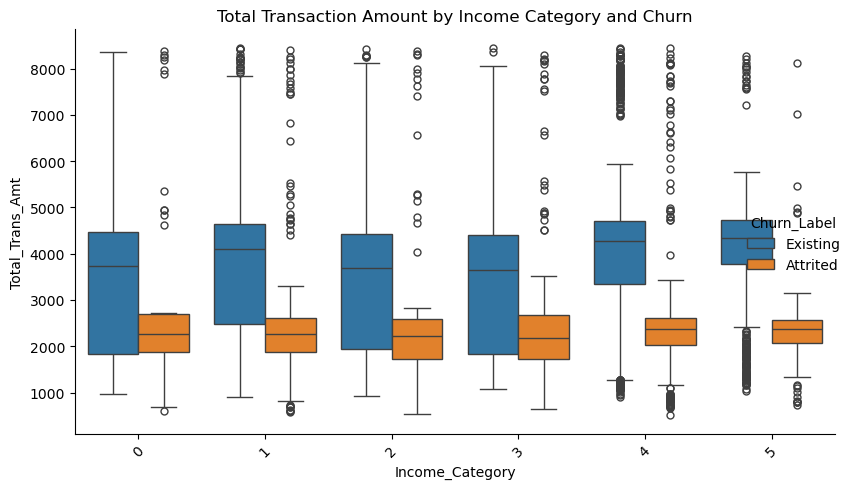

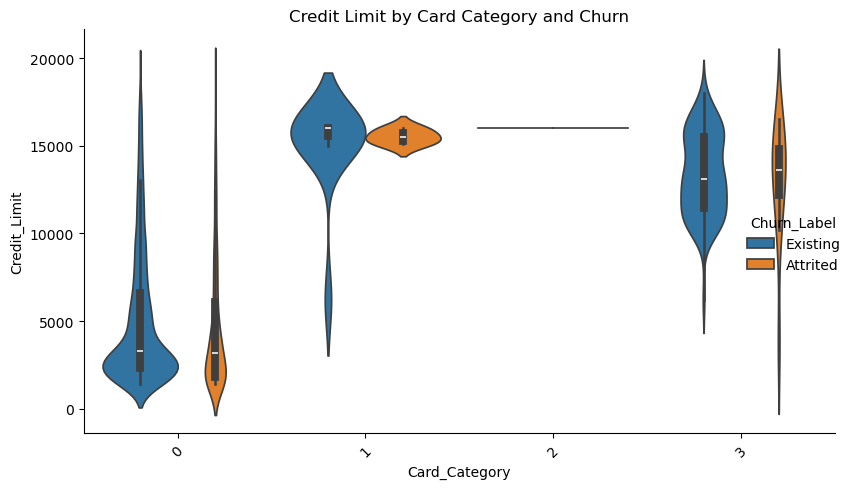

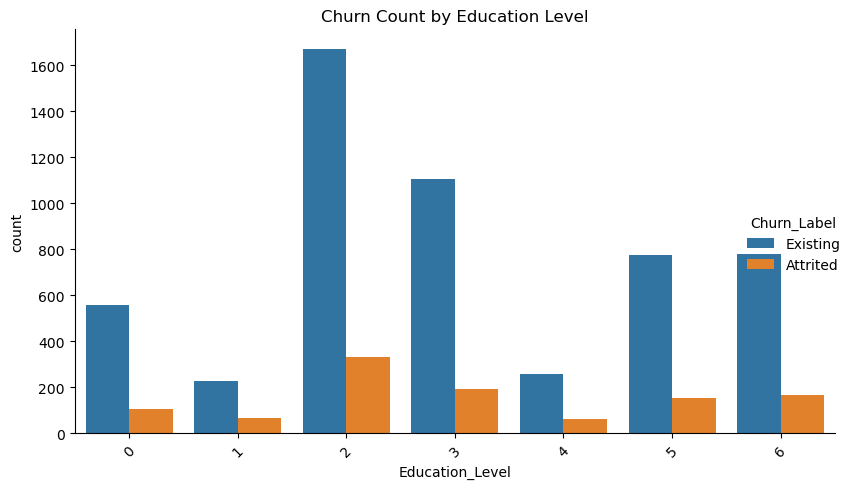

In [25]:

# Replace 0/1 in 'Churn' with descriptive labels
df['Churn_Label'] = df['Churn'].map({0: 'Existing', 1: 'Attrited'})

# 1. Transaction amount vs Income Category
sns.catplot(data=df, x="Income_Category", y="Total_Trans_Amt", hue="Churn_Label", kind="box", height=5, aspect=1.5)
plt.title("Total Transaction Amount by Income Category and Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Credit Limit by Card Category
sns.catplot(data=df, x="Card_Category", y="Credit_Limit", hue="Churn_Label", kind="violin", height=5, aspect=1.5)
plt.title("Credit Limit by Card Category and Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Count of customers by Education Level and Churn
sns.catplot(data=df, x="Education_Level", hue="Churn_Label", kind="count", height=5, aspect=1.5)
plt.title("Churn Count by Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


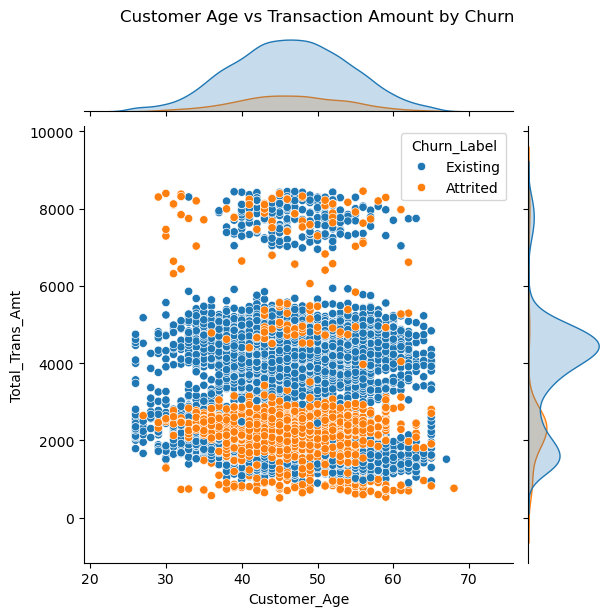

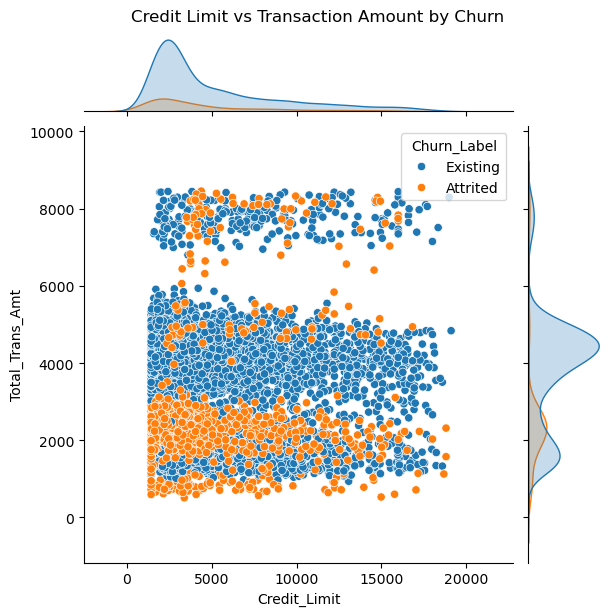

In [26]:
# Map churn values for clearer labels
df['Churn_Label'] = df['Churn'].map({0: 'Existing', 1: 'Attrited'})

# 1. Customer Age vs Total Transaction Amount
sns.jointplot(data=df, x="Customer_Age", y="Total_Trans_Amt", hue="Churn_Label", kind="scatter", height=6)
plt.suptitle("Customer Age vs Transaction Amount by Churn", y=1.02)
plt.show()

# 2. Credit Limit vs Total Transaction Amount
sns.jointplot(data=df, x="Credit_Limit", y="Total_Trans_Amt", hue="Churn_Label", kind="scatter", height=6)
plt.suptitle("Credit Limit vs Transaction Amount by Churn", y=1.02)
plt.show()


## 5. Predictive Modeling

We build logistic regression, random forest, **XGBoost**, and **AdaBoost** models to predict churn.

### 5.1 Data Preparation for Modeling
We:
- Drop `Attrition_Flag` from the dataset.
- One-hot encode the known categorical columns.
- Define features (`X`) and target (`y`).
- Perform a train-test split.

In [14]:
# Create a modeling DataFrame
df_model = df.copy()

# Drop 'Attrition_Flag' if it still exists
if 'Attrition_Flag' in df_model.columns:
    df_model.drop(columns=['Attrition_Flag'], inplace=True)

# List known categorical columns
categorical_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

# One-hot encode these columns
for col in categorical_cols:
    if col in df_model.columns:
        df_model = pd.get_dummies(df_model, columns=[col], drop_first=True)

# Define features (X) and target (y)
X = df_model.drop(columns=['Churn'], errors='ignore')
y = df_model['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train set size:", X_train.shape)
print("Test set size: ", X_test.shape)

Train set size: (4524, 32)
Test set size:  (1939, 32)


### 5.2 Logistic Regression


=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1620
           1       0.75      0.56      0.64       319

    accuracy                           0.90      1939
   macro avg       0.84      0.76      0.79      1939
weighted avg       0.89      0.90      0.89      1939



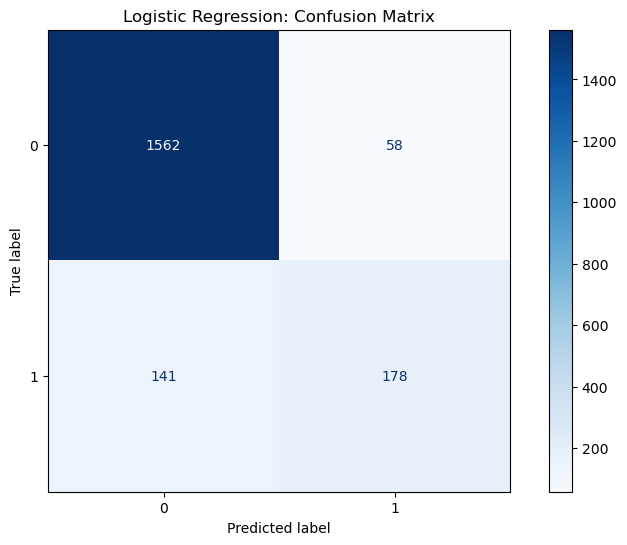

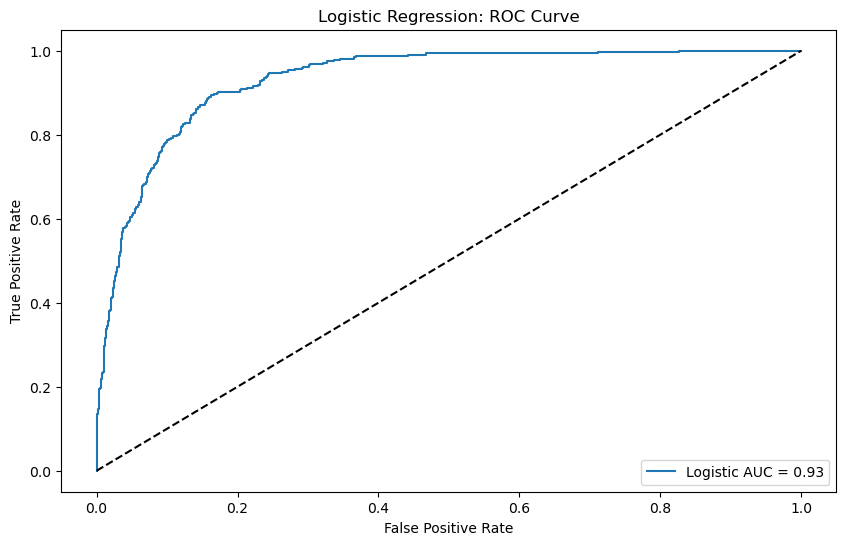

In [15]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predictions
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_logreg))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, cmap='Blues')
plt.title("Logistic Regression: Confusion Matrix")
plt.grid(False)
plt.show()

# ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_log = roc_auc_score(y_test, y_proba_logreg)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic AUC = {roc_auc_log:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression: ROC Curve")
plt.legend(loc='lower right')
plt.show()

### 5.3 Random Forest


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1620
           1       0.91      0.81      0.86       319

    accuracy                           0.96      1939
   macro avg       0.94      0.90      0.92      1939
weighted avg       0.96      0.96      0.96      1939



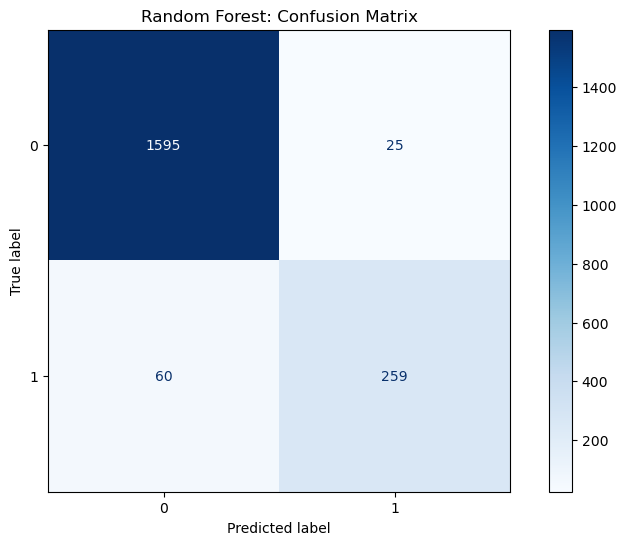

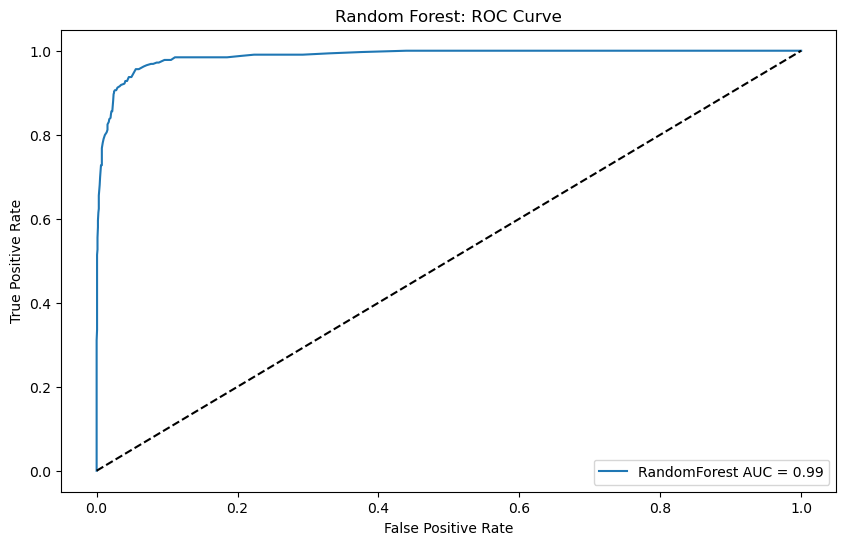

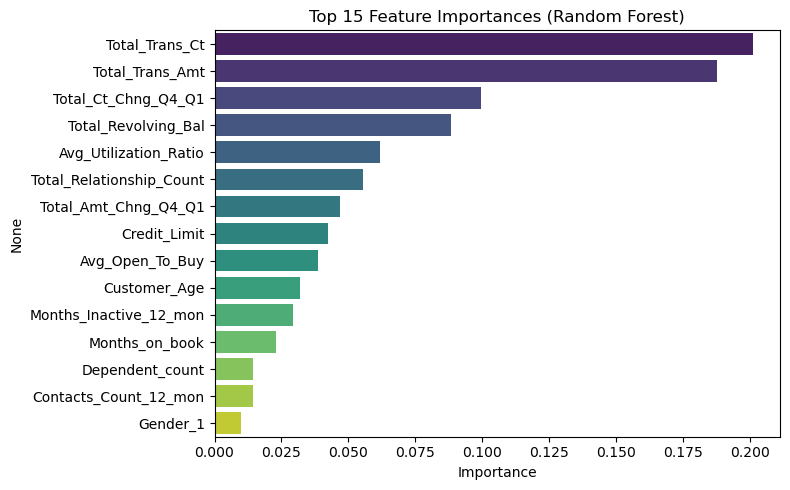

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')
plt.title("Random Forest: Confusion Matrix")
plt.grid(False)
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest AUC = {roc_auc_rf:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest: ROC Curve")
plt.legend(loc='lower right')
plt.show()

# Optional: Feature Importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 5.4 XGBoost


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1620
           1       0.91      0.92      0.92       319

    accuracy                           0.97      1939
   macro avg       0.95      0.95      0.95      1939
weighted avg       0.97      0.97      0.97      1939



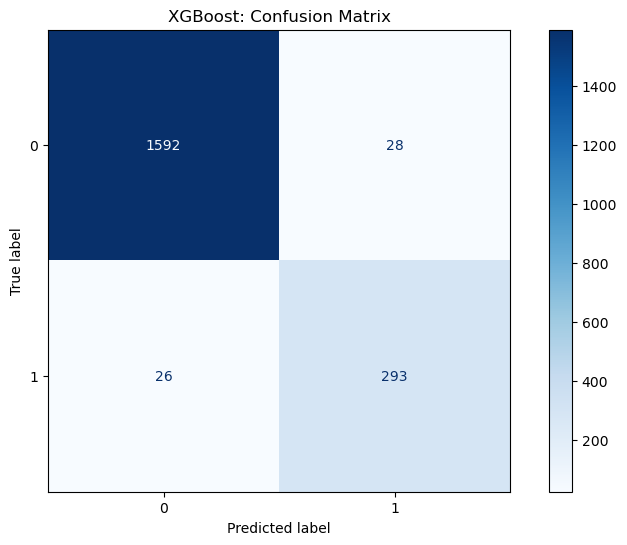

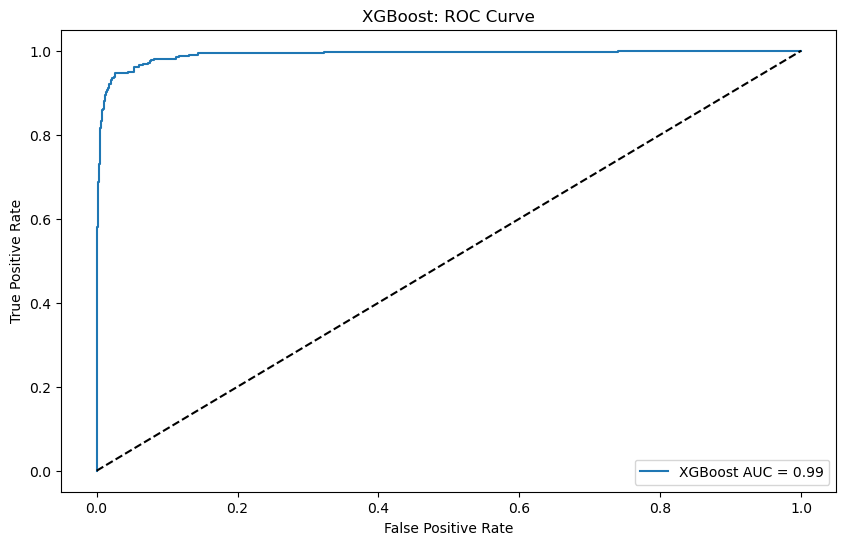

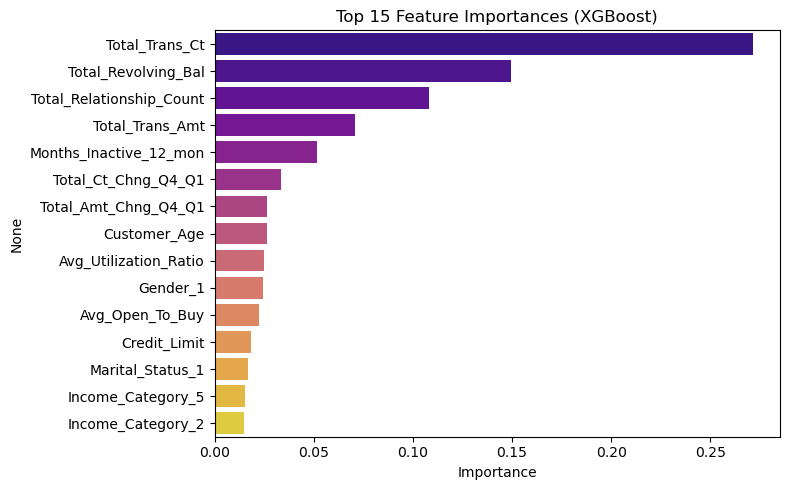

In [17]:
!pip install xgboost --quiet  # ensure xgboost is installed
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Blues')
plt.title("XGBoost: Confusion Matrix")
plt.grid(False)
plt.show()

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost: ROC Curve")
plt.legend(loc='lower right')
plt.show()

# Optional: Feature Importance
xgb_importances = pd.Series(xgb_clf.feature_importances_, index=X_train.columns)
top_features_xgb = xgb_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette='plasma')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 5.5 AdaBoost


=== AdaBoost ===
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1620
           1       0.88      0.87      0.88       319

    accuracy                           0.96      1939
   macro avg       0.93      0.92      0.93      1939
weighted avg       0.96      0.96      0.96      1939



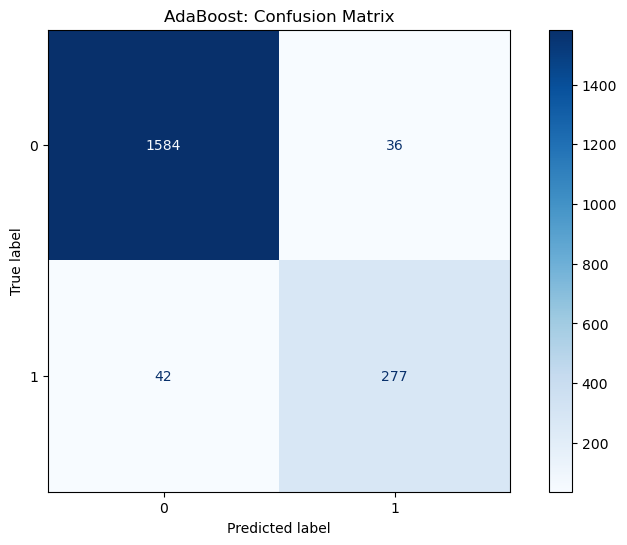

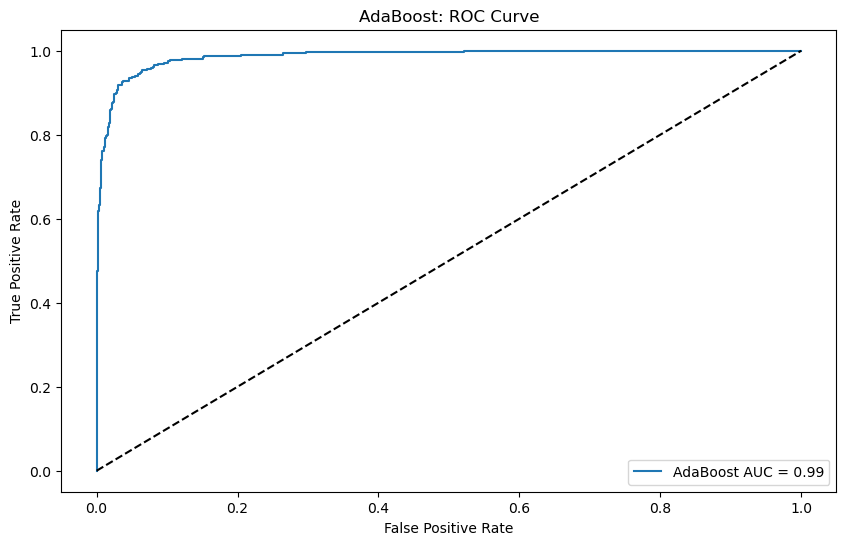

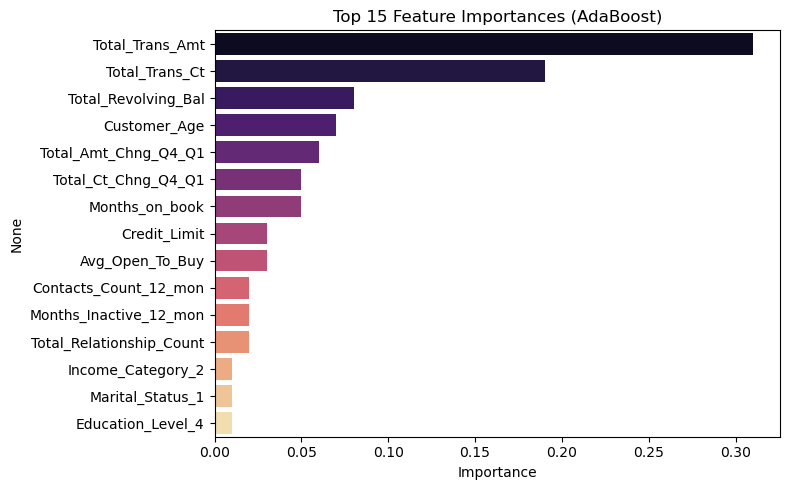

In [18]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

# Predictions
y_pred_ada = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

print("\n=== AdaBoost ===")
print("Classification Report:")
print(classification_report(y_test, y_pred_ada))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada, cmap='Blues')
plt.title("AdaBoost: Confusion Matrix")
plt.grid(False)
plt.show()

# ROC Curve
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba_ada)
roc_auc_ada = roc_auc_score(y_test, y_proba_ada)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost AUC = {roc_auc_ada:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost: ROC Curve")
plt.legend(loc='lower right')
plt.show()

# AdaBoost does not have a built-in feature_importances_ for all base estimators,
# but for many scikit-learn base estimators it does. We can attempt:
if hasattr(ada, 'feature_importances_'):
    ada_importances = pd.Series(ada.feature_importances_, index=X_train.columns)
    top_features_ada = ada_importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_features_ada.values, y=top_features_ada.index, palette='magma')
    plt.title("Top 15 Feature Importances (AdaBoost)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("AdaBoost base estimator does not expose feature_importances_.")

## 6. Conclusion

In this notebook, we:

- **Loaded** and **cleaned** the BankChurners dataset by removing unwanted columns and converting `Attrition_Flag` to a numeric `Churn`.
- **Performed** EDA, including distribution of churn, categorical/numerical analysis, and correlation.
- **Removed** outliers from numeric columns except `Churn` to preserve variation.
- **Built** four predictive models: **Logistic Regression**, **Random Forest**, **XGBoost**, and **AdaBoost**, and evaluated each using classification reports, confusion matrices, and ROC curves.

Further improvements might include more advanced feature engineering, hyperparameter tuning (via GridSearchCV or RandomizedSearchCV), or exploring additional algorithms.